# Optimization
The topic of this notebook is optimization, that is minimizing or maximizing an objective function often under constraints represented as equations or inequalities, e.g. in two variables
$$\begin{align*}
& \min_{x,y} f(x,y) \\ 
& \textrm{s.t.}  \ x \gt 0, \ y \gt 0 
\end{align*}$$
If the objective function and the constraints are linear thee problem is classified as **linear programming**. Generally optimization problems are very difficult to solve. One problem is that an algorithm may stop at a local minimum and fail to find the global one. A particular class of optimization problems are those called **convex problems**. A function that is convex in an interval $[a,b]$ has only one global minimum and no local ones. Minimizing an objective function $f(x,y)$ means finding the roots of its derivative, or of the components of its gradient
$$\nabla f(x,y) = 0 $$
The root points $(x^*,y^*)$ can be a minimum, maximum or saddle point. In order to distinguish the type of point we need the 2nd derivative, or the hessian
$$H(x,y)=\frac{\partial^{2} f(x,y)}{\partial x_{i} \partial x_{j}}$$
If $H(x^*,y^*) \gt 0$ then $(x^*,y^*)$ is a minimum, if $H(x^*,y^*) \lt 0$ $(x^*,y^*)$ is a maximum and if $H(x^*,y^*) = 0$ then $(x^*,y^*)$ is a saddle point.  
The examples in this notebook follow those from chapter 6 of the book by Johansson [*Numerical Python, 3rd Edition*](https://github.com/jrjohansson/numerical-python-book-code/blob/master/ch06-code-listing.ipynb). 

In [1]:
import numpy as np
import sympy
import scipy
from scipy import linalg as la
import matplotlib as mpl
import matplotlib.pyplot as plt
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('SciPy version: {}'.format(scipy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
SciPy version: 1.17.1
Matplotlib version: 3.8.4


## Univariate optimization
In order to find the minimum of an univariate objective function we can use the same techniques, such as the [Newton method](https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization), that we saw to find the roots of an equation of the type $f'(x) = 0$ with f' being the first derivative of $f(x)$. The Newton method for optimization involves the computation of the second derivative $f''(x)$. The [SciPy optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html#optimization) module provides methods for the optimization of a scalar univariate function. As an example we find the minimum area of a cylinder with constant (unit) volume. The area of a cylinder depends on two variables: its radius and height. We write the minimization problems as
$$\begin{align*}
& \min_{r,h} A = 2 \pi r^2 + 2 \pi r h \\ 
& \textrm{s.t.} \ \pi r^2 h = 1 
\end{align*}$$
From the expression of the constraint we have  
$$h = \frac{1}{\pi r^2}$$ 
Substituting into the objective function we have the function to be minimized 
$$A = 2 \pi r^2 + \frac{2}{r}$$

In [2]:
def f(r):
    return 2 * np.pi * r**2 + 2 / r

In [6]:
from scipy import optimize
opt = optimize.minimize_scalar(f, bracket=(0.1, 4))
opt

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 5.535810445932086
       x: 0.5419260772557135
     nit: 15
    nfev: 18

In [9]:
r_min = opt['x']
r_min

0.5419260772557135

In [5]:
r = np.linspace(0, 2, 100)[1:]

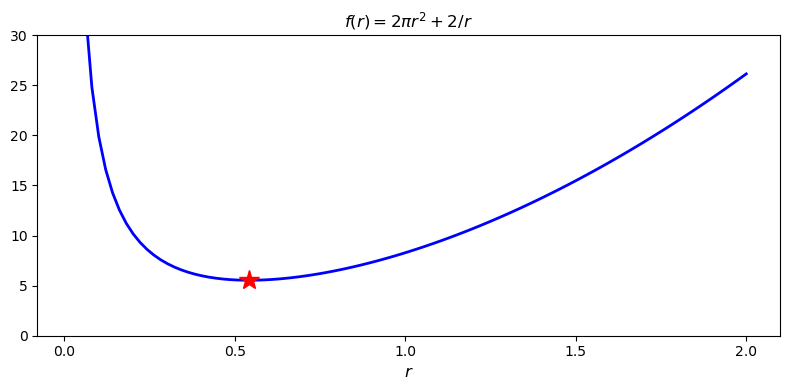

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r, f(r), lw=2, color='b')
ax.plot(r_min, f(r_min), 'r*', markersize=15)
ax.set_title(r"$f(r) = 2\pi r^2+2/r$", fontsize=12)
ax.set_xlabel(r"$r$", fontsize=12)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_ylim(0, 30)
fig.tight_layout()